In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Load the traffic dataset

file_path = "PeMSD7_V_228.csv"
data = pd.read_csv(file_path, header=None)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [14]:
# Create meaningful column names for the 228 traffic sensors

data.columns = [f"Sensor_{i+1}" for i in range(data.shape[1])]
print("Column names assigned successfully!")

Column names assigned successfully!


In [15]:
# Dataset Exploration

print("Number of observations:", data.shape[0])

print("Number of attributes:", data.shape[1])

Number of observations: 12672
Number of attributes: 228


In [16]:
# Display the first 5 rows of the dataset

data.head()

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_219,Sensor_220,Sensor_221,Sensor_222,Sensor_223,Sensor_224,Sensor_225,Sensor_226,Sensor_227,Sensor_228
0,71.1,66.0,64.6,65.6,67.1,71.9,68.6,67.7,65.8,40.9,...,69.1,70.9,65.0,64.5,66.6,66.6,65.0,69.3,67.7,68.9
1,68.1,66.8,61.7,66.7,64.5,71.6,72.3,64.9,65.6,40.1,...,70.6,65.4,65.0,64.9,65.1,67.7,65.0,67.7,68.8,68.8
2,68.0,64.3,66.6,68.7,68.1,70.5,70.2,61.7,63.4,39.6,...,72.2,70.5,65.0,64.7,66.7,68.9,65.0,70.2,69.1,68.7
3,68.3,67.8,65.9,66.6,67.9,70.3,69.8,67.6,63.2,37.6,...,71.2,69.7,65.0,65.2,67.2,66.9,65.0,70.4,67.3,69.0
4,68.9,69.5,61.2,67.4,64.0,68.1,67.0,66.7,64.2,36.8,...,71.3,65.8,65.0,66.3,66.7,66.2,65.0,68.0,67.4,68.1


In [17]:
# Check for missing values in the dataset
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [18]:
# Check for duplicate rows
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [19]:
# Display basic information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12672 entries, 0 to 12671
Columns: 228 entries, Sensor_1 to Sensor_228
dtypes: float64(228)
memory usage: 22.0 MB


In [20]:

# FEATURE ENGINEERING
data["Average_Traffic"] = data.iloc[:, :228].mean(axis=1)

# Display the first 5 values
data["Average_Traffic"].head()

0    67.541228
1    67.479386
2    67.413158
3    67.305263
4    66.953070
Name: Average_Traffic, dtype: float64

In [21]:

import pandas as pd

file_path = "PeMSD7_V_228.csv"

data = pd.read_csv(file_path, header=None)
data.columns = [f"Sensor_{i+1}" for i in range(data.shape[1])]

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [22]:

# FEATURE ENGINEERING


data["Average_Traffic"] = data.iloc[:, :228].mean(axis=1)

# Display the first 5 values
data["Average_Traffic"].head()

0    67.541228
1    67.479386
2    67.413158
3    67.305263
4    66.953070
Name: Average_Traffic, dtype: float64

In [23]:
# Display the first 5 rows of the new feature

print("Average traffic feature created successfully!")

data[["Average_Traffic"]].head()

Average traffic feature created successfully!


,Average_Traffic
0,67.541228
1,67.479386
2,67.413158
3,67.305263
4,66.953070


In [24]:
     # Explore the newly created Average_Traffic feature

print("Minimum:", data["Average_Traffic"].min())
print("Maximum:", data["Average_Traffic"].max())
print("Mean:", data["Average_Traffic"].mean())
print("Median:", data["Average_Traffic"].median())

Minimum: 35.640350877193
Maximum: 69.78377192982458
Mean: 58.88918398624402
Median: 59.547807017543846


In [25]:
# Congestion level thresholds

low_threshold = data["Average_Traffic"].quantile(0.33)
high_threshold = data["Average_Traffic"].quantile(0.67)

print("Low threshold:", low_threshold)
print("High threshold:", high_threshold)

Low threshold: 56.010026315789474
High threshold: 65.83201754385965


In [26]:
# Create the Congestion Level target variable

data["Congestion_Level"] = pd.cut(
    data["Average_Traffic"],
    bins=[-np.inf, low_threshold, high_threshold, np.inf],
    labels=["Low", "Medium", "High"]
)

# Display the first 10 congestion levels
data[["Average_Traffic", "Congestion_Level"]].head(10)

,Average_Traffic,Congestion_Level
0,67.541228,High
1,67.479386,High
2,67.413158,High
3,67.305263,High
4,66.953070,High
5,66.660088,High
6,66.325877,High
7,66.479825,High
8,66.391228,High
9,66.567105,High


In [27]:
# Import NumPy

import numpy as np

In [28]:
# Create the Congestion Level target variable

data["Congestion_Level"] = pd.cut(
    data["Average_Traffic"],
    bins=[-np.inf, low_threshold, high_threshold, np.inf],
    labels=["Low", "Medium", "High"]
)

# Display the first 10 congestion levels

data[["Average_Traffic", "Congestion_Level"]].head(10)

,Average_Traffic,Congestion_Level
0,67.541228,High
1,67.479386,High
2,67.413158,High
3,67.305263,High
4,66.953070,High
5,66.660088,High
6,66.325877,High
7,66.479825,High
8,66.391228,High
9,66.567105,High


In [29]:
# Check the number of observations in each congestion level

print(data["Congestion_Level"].value_counts())


Congestion_Level
Medium    4309
Low       4182
High      4181
Name: count, dtype: int64


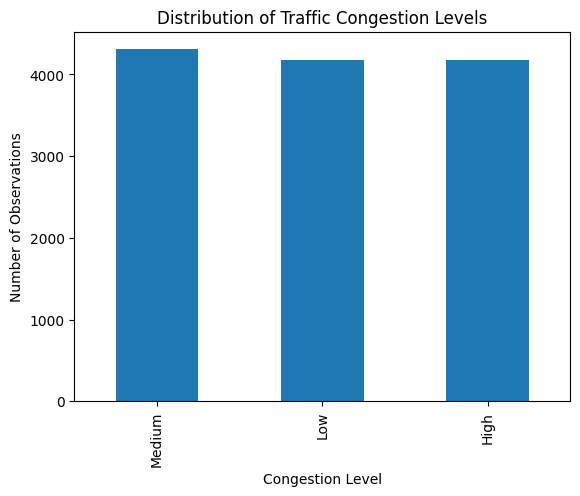

In [30]:
# Visualize the number of observations in each congestion level

data["Congestion_Level"].value_counts().plot(kind="bar")

plt.xlabel("Congestion Level")
plt.ylabel("Number of Observations")
plt.title("Distribution of Traffic Congestion Levels")

plt.show()

In [31]:
# Import Matplotlib for plotting

import matplotlib.pyplot as plt

In [32]:
# Separate input features and target variable

X = data.drop(columns=["Congestion_Level"])
y = data["Congestion_Level"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (12672, 229)
Target shape: (12672,)


In [33]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes of the datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (10137, 229)
Testing features: (2535, 229)
Training target: (10137,)
Testing target: (2535,)


In [34]:
# Install scikit-learn

%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
# Import train_test_split

from sklearn.model_selection import train_test_split

In [36]:
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (10137, 229)
Testing features: (2535, 229)
Training target: (10137,)
Testing target: (2535,)


In [37]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully!")

Random Forest imported successfully!


In [38]:
# Create Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [39]:
# Train the Random Forest model

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [40]:
# Make predictions using the Random Forest model

y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [41]:
# Display the first 10 predictions

print("Actual values:")
print(y_test.head(10).to_list())

print("\nPredicted values:")
print(y_pred_rf[:10])

Actual values:
['High', 'Medium', 'High', 'Medium', 'Medium', 'Low', 'Medium', 'High', 'High', 'Medium']

Predicted values:
['High' 'Medium' 'High' 'Medium' 'Medium' 'Low' 'Medium' 'High' 'High'
 'Medium']


In [42]:
# Gradient Boosting Model

from sklearn.ensemble import GradientBoostingClassifier

print("Gradient Boosting imported successfully!")

Gradient Boosting imported successfully!


In [44]:
# Create Gradient Boosting classifier

gb_model = GradientBoostingClassifier(
    n_estimators=30,
    random_state=42
)

print("Gradient Boosting model created successfully!")

Gradient Boosting model created successfully!


In [45]:
# Train the Gradient Boosting model

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [46]:
# Recreate the training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training and testing data recreated successfully!")

Training and testing data recreated successfully!


In [47]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (10137, 229)
Testing features: (2535, 229)


In [48]:
# Train the Gradient Boosting model

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [49]:
# Train the Gradient Boosting model

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [50]:
# Make predictions using Gradient Boosting

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting predictions completed!")

Gradient Boosting predictions completed!


In [51]:
# Import evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [52]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test, y_pred_rf, average="weighted"
)

rf_recall = recall_score(
    y_test, y_pred_rf, average="weighted"
)

rf_f1 = f1_score(
    y_test, y_pred_rf, average="weighted"
)

print("Random Forest Evaluation")
print("------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

Random Forest Evaluation
------------------------
Accuracy : 0.9988165680473373
Precision: 0.9988206724356123
Recall   : 0.9988165680473373
F1-Score : 0.9988170056037373


In [53]:
# Evaluate Gradient Boosting

gb_accuracy = accuracy_score(y_test, y_pred_gb)

gb_precision = precision_score(
    y_test, y_pred_gb, average="weighted"
)

gb_recall = recall_score(
    y_test, y_pred_gb, average="weighted"
)

gb_f1 = f1_score(
    y_test, y_pred_gb, average="weighted"
)

print("Gradient Boosting Evaluation")
print("----------------------------")
print("Accuracy :", gb_accuracy)
print("Precision:", gb_precision)
print("Recall   :", gb_recall)
print("F1-Score :", gb_f1)

Gradient Boosting Evaluation
----------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [54]:
# Compare Random Forest and Gradient Boosting

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "Accuracy": [rf_accuracy, gb_accuracy],
    "Precision": [rf_precision, gb_precision],
    "Recall": [rf_recall, gb_recall],
    "F1-Score": [rf_f1, gb_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.998817,0.998821,0.998817,0.998817
1,Gradient Boosting,1.000000,1.000000,1.000000,1.000000


In [55]:
# Identify the model with the highest F1-score

best_model = comparison.loc[
    comparison["F1-Score"].idxmax(), "Model"
]

print("Best model based on F1-Score:", best_model)

Best model based on F1-Score: Gradient Boosting


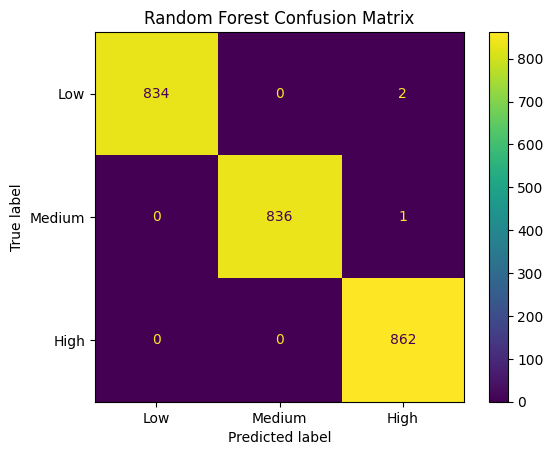

In [56]:
# Random Forest Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Low", "Medium", "High"]
)

disp_rf.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

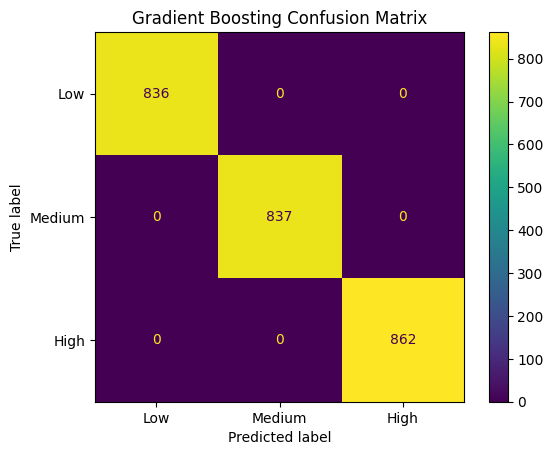

In [57]:
# Gradient Boosting Confusion Matrix

cm_gb = confusion_matrix(y_test, y_pred_gb)

disp_gb = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["Low", "Medium", "High"]
)

disp_gb.plot()

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [58]:
# Final Model Comparison

print(comparison)

print("\nBest Model based on F1-Score:")
print(best_model)

               Model  Accuracy  Precision    Recall  F1-Score
0      Random Forest  0.998817   0.998821  0.998817  0.998817
1  Gradient Boosting  1.000000   1.000000  1.000000  1.000000

Best Model based on F1-Score:
Gradient Boosting


In [59]:
# Save model comparison results

comparison.to_csv("model_comparison.csv", index=False)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [60]:
# Final Project Conclusion

print("Project completed successfully!")
print("Best performing model:", best_model)
print("The models were evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.")

Project completed successfully!
Best performing model: Gradient Boosting
The models were evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
